In [1]:
!pip install pandas numpy scikit-learn nltk streamlit matplotlib seaborn wordcloud joblib

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import PassiveAggressiveClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv(  # Temizlenmiş ve güncellenmiş dataset yükleniyor.
    "../data/updated_news_dataset.csv"
)

In [4]:
X = df["clean_text"] # Modelin giriş verisi. Yani haber metinleri.

y = df["label"] # Tahmin edilmesi gereken sonuçlar. 0 → Fake 1 → Real

In [5]:
X_train, X_test, y_train, y_test = train_test_split( # Dataset eğitim ve test olarak bölünüyor.

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [6]:
vectorizer = TfidfVectorizer(

    max_df=0.7,

    min_df=2,

    ngram_range=(1,2),

    stop_words="english"

)

In [7]:
X_train_tfidf = vectorizer.fit_transform(   # TF-IDF: kelimeleri öğrenir sayısal vektöre dönüştürür
    X_train
)

X_test_tfidf = vectorizer.transform(  # Test verisini aynı sisteme göre sayısal hale getirir.
    X_test
)

In [8]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit( # Model eğitilir.
    X_train_tfidf,
    y_train
)

lr_pred = lr_model.predict( # Model test verileri üzerinde tahmin yapar.
    X_test_tfidf
)

lr_accuracy = accuracy_score( # Doğruluk oranı hesaplanır.
    y_test,
    lr_pred
)

print(
    "Logistic Regression Accuracy:",
    lr_accuracy
)

print(
    classification_report( # Detaylı performans raporu verir.
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy: 0.9737234186644995
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3340
           1       0.97      0.98      0.98      4043

    accuracy                           0.97      7383
   macro avg       0.97      0.97      0.97      7383
weighted avg       0.97      0.97      0.97      7383



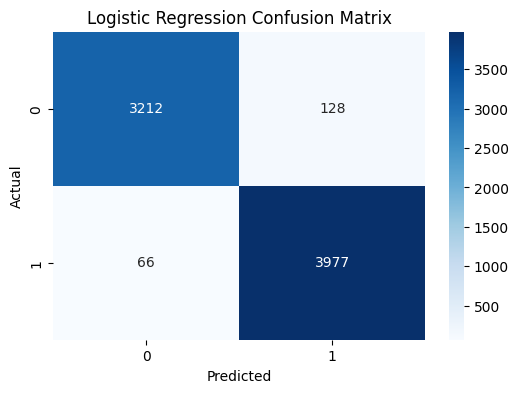

In [9]:
cm_lr = confusion_matrix( # Karışıklık matrisi oluşturur.
    y_test,
    lr_pred
)

plt.figure(figsize=(6,4))

sns.heatmap( # Confusion matrix görselleştirilir.
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [10]:
pa_model = PassiveAggressiveClassifier(
    max_iter=1000
)

pa_model.fit(
    X_train_tfidf,
    y_train
)

pa_pred = pa_model.predict(
    X_test_tfidf
)

pa_accuracy = accuracy_score(
    y_test,
    pa_pred
)

print(
    "PassiveAggressive Accuracy:",
    pa_accuracy
)

print(
    classification_report(
        y_test,
        pa_pred
    )
)

c:\Users\asus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


PassiveAggressive Accuracy: 0.9863199241500745
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3340
           1       0.98      0.99      0.99      4043

    accuracy                           0.99      7383
   macro avg       0.99      0.99      0.99      7383
weighted avg       0.99      0.99      0.99      7383



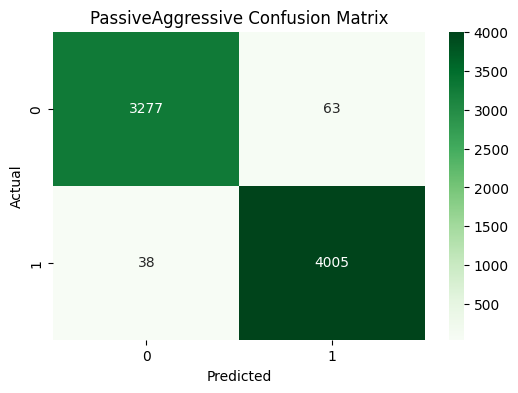

In [11]:
cm_pa = confusion_matrix(
    y_test,
    pa_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_pa,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "PassiveAggressive Confusion Matrix"
)

plt.show()

In [12]:
results = pd.DataFrame({

    "Model": [

        "Logistic Regression",

        "PassiveAggressive"

    ],

    "Accuracy": [

        lr_accuracy,

        pa_accuracy

    ]

})

results

,Model,Accuracy
0,Logistic Regression,0.973723
1,PassiveAggressive,0.986320


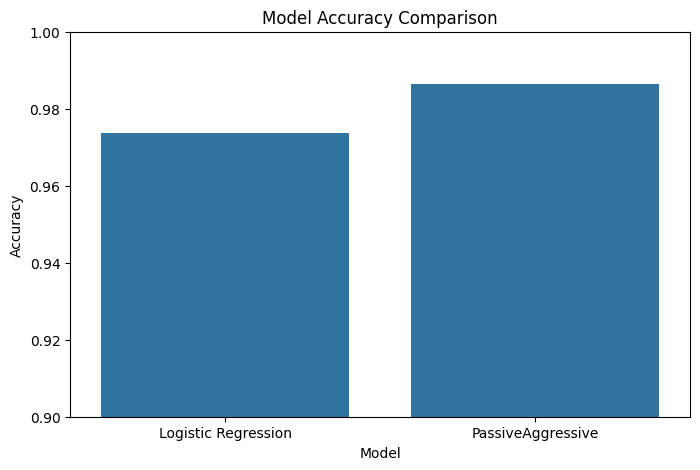

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylim(0.9, 1.0)

plt.show()